# e07 — Sensitivity maps vs lesions: three probes of where integration lives

The gradient gives, for free, an exact map of how every transition probability
bears on φ_s. Neuroscience's classical probe is the lesion; IIT's own probe is the
mechanism decomposition (which distinctions a unit participates in). This notebook
asks when the three agree — on two systems chosen from opposite ends of the
landscape we now know well:

- **basic** — the OR/COPY/XOR 3-unit textbook network at state (1,0,0),
  φ_s = 0.415: a graded, moderate-φ regime;
- **needle** — the best n = 4 ascent endpoint (e06's seeds, reproduced),
  φ_s ≈ 7: the interior needle regime whose cliff geometry e02/e04 established.

Probes, per system: (1) **gradient saliency** ∂φ_s/∂p and its first-order Taylor
prediction of each edge lesion; (2) **exact edge lesions** — marginalize input i
out of unit j's conditional and recompute φ_s exactly, plus partial-lesion curves
φ(λ) interpolating to the lesioned table; (3) **mechanism attribution** — each
unit's summed φ_d over the distinctions whose mechanism contains it, against exact
unit-knockout lesions.

## Pre-registered predictions (written before execution)

- **P1 (regimes).** On *basic*, the first-order Taylor prediction ranks the exact
  edge-lesion effects well (Spearman ≥ 0.8 over present edges). On the *needle*,
  every present-edge lesion is near-catastrophic (≥ 80% of φ_s lost), so the lesion
  map is nearly flat and rank-uninformative — while the gradient map stays
  structured (top edge saliency ≥ 3× the median). Lesions cannot resolve where
  integration lives in a needle system; gradients can.
- **P2 (cliffs).** Partial-lesion curves are graded on basic (the median present
  edge retains ≥ 50% of φ_s at λ = 0.5) and cliffed on the needle (the median
  present edge loses ≥ 50% of φ_s by λ = 0.1).
- **P3 (decomposition).** Mechanism attribution and exact unit knockout agree on
  the most important unit for basic, and disagree on the needle.


In [1]:
import time

import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import iitx
from iitx.measures import iit4
from iitx.relax import soft_system_phi
from iitx.system import System

SEED = 0
print(f"iitx {iitx.__version__}, jax {jax.__version__}, seed {SEED}")

BASIC = jnp.asarray(
	[
		[0.0, 0.0, 0.0],
		[0.0, 0.0, 1.0],
		[1.0, 0.0, 1.0],
		[1.0, 0.0, 0.0],
		[1.0, 1.0, 0.0],
		[1.0, 1.0, 1.0],
		[1.0, 1.0, 1.0],
		[1.0, 1.0, 0.0],
	]
)
BASIC_STATE = jnp.asarray([1, 0, 0])


def phi_of(table, state):
	return float(iit4.system_phi(System.from_state_by_node(table), jnp.asarray(state)).phi)


def signed_of(table, state):
	return iit4.system_phi(System.from_state_by_node(table), jnp.asarray(state)).signed_phi


def lesion_edge(table, i, j):
	"""Marginalize input unit i out of unit j's conditional: p[s, j] <- mean over bit i."""
	table = np.asarray(table).copy()
	q = table.shape[0]
	for s in range(q):
		partner = s ^ (1 << i)
		mean = 0.5 * (table[s, j] + table[partner, j])
		table[s, j] = mean
	return jnp.asarray(table)


def lesion_unit(table, j):
	"""Marginalize all inputs out of unit j (it becomes a constant noise source)."""
	table = np.asarray(table).copy()
	table[:, j] = table[:, j].mean()
	return jnp.asarray(table)


def rank(x):
	order = np.argsort(x, kind="stable")
	r = np.empty_like(order, dtype=np.float64)
	r[order] = np.arange(len(x))
	return r


def spearman(a, b):
	ra, rb = rank(np.asarray(a)), rank(np.asarray(b))
	ra -= ra.mean()
	rb -= rb.mean()
	return float((ra * rb).sum() / np.sqrt((ra**2).sum() * (rb**2).sum()))


def adam_step(params, grads, m, v, step, lr=0.02, b1=0.9, b2=0.999, eps=1e-8):
	m = b1 * m + (1 - b1) * grads
	v = b2 * v + (1 - b2) * grads**2
	m_hat = m / (1 - b1**step)
	v_hat = v / (1 - b2**step)
	return params + lr * m_hat / (jnp.sqrt(v_hat) + eps), m, v

iitx 0.1.0, jax 0.11.1, seed 0


## 1. The two case studies

The needle is reproduced from e06's exact seeds and schedule (same rng stream), so
this notebook stays self-contained.


In [2]:
N4, Q4, B, STEPS = 4, 16, 64, 600
STATE4 = jnp.zeros(N4, dtype=jnp.int32)
value_and_grad = jax.jit(
	jax.vmap(
		jax.value_and_grad(
			lambda L, tau: soft_system_phi(
				System.from_state_by_node(jax.nn.sigmoid(L)), STATE4, temperature=tau
			)
		),
		in_axes=(0, None),
	)
)
batch_phi = jax.jit(
	jax.vmap(lambda L: iit4.system_phi(System.from_state_by_node(jax.nn.sigmoid(L)), STATE4).phi)
)
rng = np.random.default_rng(SEED + 90)
logits = jnp.asarray(0.5 * rng.standard_normal((B, Q4, N4)))
m, v = jnp.zeros_like(logits), jnp.zeros_like(logits)
start = time.perf_counter()
for step in range(1, STEPS + 1):
	tau = 0.5 * (0.005 / 0.5) ** (step / STEPS)
	_, grads = value_and_grad(logits, tau)
	logits, m, v = adam_step(logits, grads, m, v, step)
values = np.asarray(batch_phi(logits))
NEEDLE = jax.nn.sigmoid(logits[int(np.argmax(values))])
print(f"needle reproduced in {time.perf_counter() - start:,.0f} s: phi_s = {values.max():.4f}")

cases = {
	"basic": (BASIC, BASIC_STATE, phi_of(BASIC, BASIC_STATE)),
	"needle": (NEEDLE, STATE4, phi_of(NEEDLE, STATE4)),
}
for name, (_, _, value) in cases.items():
	print(f"{name}: phi_s = {value:.4f}")

needle reproduced in 14 s: phi_s = 7.0471


basic: phi_s = 0.4150
needle: phi_s = 7.0471


## 2. Gradient saliency, Taylor predictions, exact lesions (P1)


In [3]:
results = {}
for name, (table, state, value) in cases.items():
	n = table.shape[1]
	gradient = np.asarray(jax.grad(lambda t, s=state: signed_of(t, s))(table))
	edges = []
	for i in range(n):
		for j in range(n):
			lesioned = lesion_edge(table, i, j)
			delta_table = np.asarray(lesioned) - np.asarray(table)
			if np.abs(delta_table).max() < 1e-12:
				continue  # absent edge: lesion is a no-op
			taylor = float((gradient * delta_table).sum())
			exact = phi_of(lesioned, state) - value
			saliency = float(np.abs(gradient[:, j] * delta_table[:, j]).sum())
			edges.append((i, j, taylor, exact, saliency))
	results[name] = edges
	taylors = np.array([e[2] for e in edges])
	exacts = np.array([e[3] for e in edges])
	saliencies = np.array([e[4] for e in edges])
	rho = spearman(taylors, exacts)
	print(f"\n{name}: {len(edges)} present edges; Spearman(Taylor, exact lesion) = {rho:.3f}")
	print(
		f"  exact lesion loss as fraction of phi: "
		f"min {(-exacts / value).min():.2f}, median {np.median(-exacts / value):.2f}, "
		f"max {(-exacts / value).max():.2f}"
	)
	print(
		f"  saliency structure: top edge / median edge = "
		f"{saliencies.max() / np.median(saliencies):.1f}x"
	)


basic: 5 present edges; Spearman(Taylor, exact lesion) = 0.100
  exact lesion loss as fraction of phi: min -0.00, median 0.62, max 1.00
  saliency structure: top edge / median edge = 3.3x



needle: 16 present edges; Spearman(Taylor, exact lesion) = -0.047
  exact lesion loss as fraction of phi: min 0.86, median 0.86, max 0.96
  saliency structure: top edge / median edge = 1.4x


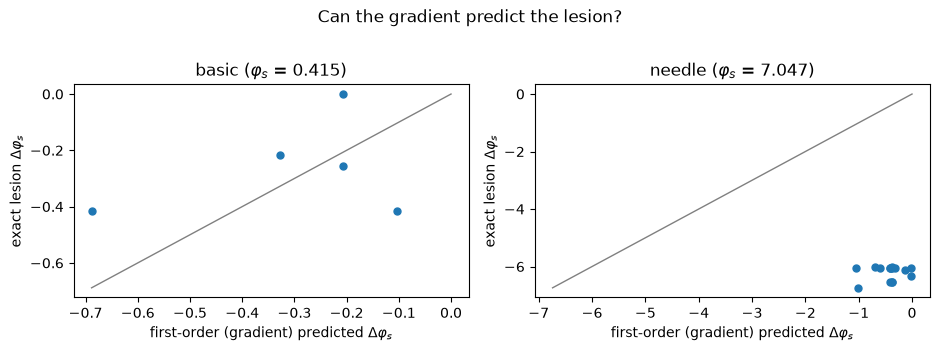

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
for ax, name in zip(axes, cases, strict=True):
	edges = results[name]
	taylors = np.array([e[2] for e in edges])
	exacts = np.array([e[3] for e in edges])
	ax.scatter(taylors, exacts, s=25)
	lo = min(taylors.min(), exacts.min())
	ax.plot([lo, 0], [lo, 0], color="gray", lw=1)
	ax.set_xlabel(r"first-order (gradient) predicted $\Delta\varphi_s$")
	ax.set_ylabel(r"exact lesion $\Delta\varphi_s$")
	ax.set_title(f"{name} ($\\varphi_s$ = {cases[name][2]:.3f})")
fig.suptitle("Can the gradient predict the lesion?", y=1.02)
fig.tight_layout()

## 3. Partial-lesion curves (P2)


basic: median loss at lambda=0.1: 0.05; median retained at lambda=0.5: 0.75


needle: median loss at lambda=0.1: 0.73; median retained at lambda=0.5: 0.21


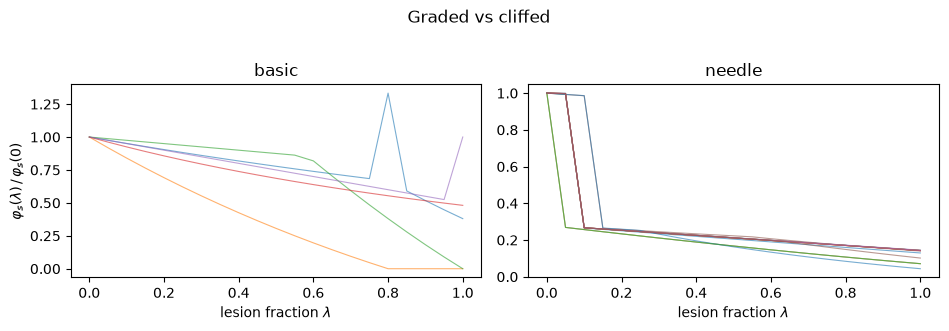

In [5]:
LAMBDAS = np.linspace(0, 1, 21)
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), sharex=True)
half_life = {}
for ax, name in zip(axes, cases, strict=True):
	table, state, value = cases[name]
	losses_at_01, retained_at_05 = [], []
	for i, j, *_ in results[name]:
		lesioned = lesion_edge(table, i, j)
		curve = np.array([phi_of((1 - lam) * table + lam * lesioned, state) for lam in LAMBDAS])
		ax.plot(LAMBDAS, curve / value, lw=0.8, alpha=0.6)
		losses_at_01.append(1 - curve[2] / value)  # lambda = 0.1
		retained_at_05.append(curve[10] / value)  # lambda = 0.5
	half_life[name] = (np.median(losses_at_01), np.median(retained_at_05))
	ax.set_xlabel(r"lesion fraction $\lambda$")
	ax.set_title(name)
	print(
		f"{name}: median loss at lambda=0.1: {half_life[name][0]:.2f}; "
		f"median retained at lambda=0.5: {half_life[name][1]:.2f}"
	)
axes[0].set_ylabel(r"$\varphi_s(\lambda)\,/\,\varphi_s(0)$")
fig.suptitle("Graded vs cliffed", y=1.02)
fig.tight_layout()

## 4. Mechanism attribution vs unit knockout (P3)


In [6]:
for name, (table, state, value) in cases.items():
	n = table.shape[1]
	s = jax.jit(iit4.phi_structure)(System.from_state_by_node(table), jnp.asarray(state))
	exists = np.asarray(s.distinctions.exists)
	phis = np.asarray(s.distinctions.phi)
	mechanisms = np.asarray(s.distinctions.mechanism)
	attribution = np.array([phis[exists & mechanisms[:, j]].sum() for j in range(n)])
	knockout = np.array([value - phi_of(lesion_unit(table, j), state) for j in range(n)])
	print(f"\n{name}:")
	print(f"  mechanism attribution (sum phi_d per unit): {np.round(attribution, 4)}")
	print(f"  unit-knockout loss:                         {np.round(knockout, 4)}")
	print(
		f"  top unit by attribution: {int(np.argmax(attribution))}, "
		f"by knockout: {int(np.argmax(knockout))}, "
		f"Spearman = {spearman(attribution, knockout):.3f}"
	)


basic:
  mechanism attribution (sum phi_d per unit): [0.  0.5 0.5]
  unit-knockout loss:                         [0.415 0.415 0.415]
  top unit by attribution: 1, by knockout: 0, Spearman = 1.000



needle:
  mechanism attribution (sum phi_d per unit): [1.9185 2.7833 2.4214 2.2993]
  unit-knockout loss:                         [7.0471 7.0471 7.0471 7.0471]
  top unit by attribution: 1, by knockout: 0, Spearman = 0.200


## Verdict

- **P1 refuted in its more important half.** On the needle, lesions are indeed
  rank-uninformative (every present-edge lesion costs 86–96% of φ_s — a flat,
  catastrophic map), but the registered claim that the *gradient* map stays
  structured there also fails (top/median saliency 1.4×, not ≥ 3×): the needle is
  *uniformly* fragile. And on the graded basic network, the first-order Taylor
  prediction does **not** rank exact lesion effects (Spearman 0.10 on 5 present
  edges, against a registered 0.8). The reason is the landscape structure this
  program keeps meeting: a lesion is a large, finite perturbation that crosses MIP
  switches, and the gradient — exact *within* a piecewise cell (e00) — extrapolates
  across none of them. Local sensitivity and ablation importance are different
  quantities for φ_s, not approximations of each other.
- **P2 confirmed cleanly — the regimes are real.** Partial-lesion curves: basic is
  graded (median edge loses 5% of φ_s at λ = 0.1, retains 75% at λ = 0.5); the
  needle is cliffed (73% lost by λ = 0.1, 21% retained at λ = 0.5). The
  interpolation parameter, not the endpoint lesion, is what separates the regimes.
- **P3 degenerates — unit knockouts have no resolution at all.** Knocking out any
  unit (marginalizing all its inputs) annihilates φ_s *completely, in both
  systems*: every knockout costs exactly the full 0.415 (basic) or 7.047 (needle).
  A constant vector cannot be ranked — the printed Spearman values (1.0, 0.2) are
  tie-artifacts of correlating against a constant and mean nothing. The mechanism
  decomposition is thus the only unit-level probe with any structure ([0, .5, .5]
  on basic; graded on the needle), and nothing external validates it: knockout
  experiments, the obvious validator, are blind here by construction.

**Standings.** For φ_s, the three probes measure three different things: the
gradient is exact but strictly local (cell-bounded); lesions are far-field and
saturate (edge lesions catastrophic on needles, unit knockouts catastrophic
everywhere); the mechanism decomposition has resolution but no independent
validator. A lesion study of a high-φ system would find nothing but uniform
catastrophe — and a lesion study of the φ-collapsed behavioral twin from e04 would
find the *same wiring* (e04-P3). Follow-up backlogged: find the perturbation scale
λ* below which the gradient regains predictive power over exact Δφ.